<a href="https://colab.research.google.com/github/25wh1a0564-ai/NASSCOM/blob/main/Week2/U4_Linear_Algebra_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
print("ndim:", T.ndim)
print("shape:", T.shape)

# 2. T + T
print("T + T:\n", T + T)

# 3. Transpose (print .T.shape) and reshape to (2, 6)
T = T.T
print("Transposed shape:", T.shape)

T = T.reshape(2, 6)
print("Reshaped array:\n", T)

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
ndim: 2
shape: (3, 4)
T + T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
Transposed shape: (4, 3)
Reshaped array:
 [[ 0  4  8  1  5  9]
 [ 2  6 10  3  7 11]]


In [3]:
import numpy as np

def cosine(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),   # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),   # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),   # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
    print(f"Pair {i}")
    print("L1 norm:", np.linalg.norm(u, 1))
    print("L2 norm:", np.linalg.norm(u, 2))
    print("Cosine similarity:", cosine(u, v))
    print()

# Most similar pair = Pair 1

Pair 1
L1 norm: 2.0
L2 norm: 1.4142135623730951
Cosine similarity: 0.9999999999999998

Pair 2
L1 norm: 6.0
L2 norm: 3.7416573867739413
Cosine similarity: 0.7142857142857143

Pair 3
L1 norm: 2.0
L2 norm: 2.0
Cosine similarity: 0.0



In [4]:
import numpy as np

M = np.array([[4., 2.],
              [2., 3.]])

P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
print(np.linalg.inv(M))
print(np.trace(M))

# 2. M @ inv(M) == I ?
I = np.eye(2)
print(np.allclose(M @ np.linalg.inv(M), I))

# 3. Is M symmetric? Is P orthogonal?
print(np.array_equal(M, M.T))
print(np.allclose(P.T @ P, np.eye(2)))

[[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
7.0
True
True
True


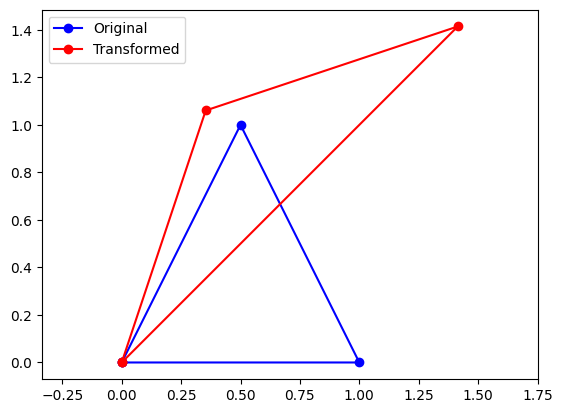

In [5]:
import numpy as np
import matplotlib.pyplot as plt

tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# Function to close the triangle for plotting
def close_loop(points):
    return np.hstack([points, points[:, :1]])

# 1. Scaling matrix (x*2, y*0.5)
S = np.array([[2, 0],
              [0, 0.5]])

# 2. Rotation matrix (45 degrees)
theta = np.deg2rad(45)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# 3. Apply scaling then rotation
transformed = R @ (S @ tri)

# Plot original and transformed triangles
plt.plot(*close_loop(tri), 'bo-', label='Original')
plt.plot(*close_loop(transformed), 'ro-', label='Transformed')
plt.axis('equal')
plt.legend()
plt.show()

In [6]:
import numpy as np
import numpy.linalg as la

C = np.array([[4., 1.],
              [2., 3.]])

# 1. eigenvalues and eigenvectors
eigenvalues, eigenvectors = la.eig(C)

# 2. print eigenvalues
print("Eigenvalues:")
print(eigenvalues)

# 3. verify A v = lambda v for the first eigenvector
v = eigenvectors[:, 0]
lam = eigenvalues[0]

print(np.allclose(C @ v, lam * v))

Eigenvalues:
[5. 2.]
True


In [7]:
import numpy as np

A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

def cosine(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# 1. Solve A2 x = b2
x = np.linalg.solve(A2, b2)
print("x =", x)

# 2. Rank of A2
print("Rank of A2:", np.linalg.matrix_rank(A2))

# 3. Cosine similarities
cat_dog = cosine(cat, dog)
cat_car = cosine(cat, car)

print("Cosine(cat, dog):", cat_dog)
print("Cosine(cat, car):", cat_car)

if cat_dog > cat_car:
    print("cat is more similar to dog")
else:
    print("cat is more similar to car")

x = [1. 2.]
Rank of A2: 2
Cosine(cat, dog): 0.9946195449838785
Cosine(cat, car): 0.29255678516966266
cat is more similar to dog
